# Project 5: Random Forest Classifier

This notebook demonstrates building, tuning, evaluating, and comparing a Random Forest Classifier on the Titanic dataset.

## Objective
1. Load and explore the Titanic dataset.
2. Split the dataset into training and testing sets to prevent data leakage.
3. Preprocess the data using scikit-learn's `ColumnTransformer` (numerical scaling + categorical one-hot encoding).
4. Build a baseline Random Forest model.
5. Hyperparameter-tune the model using `GridSearchCV` with 5-fold cross-validation.
6. Evaluate the tuned model and compare its performance against the baseline.
7. Perform feature importance analysis and visualize the results.
8. Compare models and explain the results.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Set style for plotting
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

## Data Acquisition

We load the Titanic dataset from OpenML. If the OpenML download fails, we fallback to downloading from a public raw CSV repository on GitHub. If that fails, we programmatically generate a synthetic dataset mimicking the structure of the Titanic dataset to ensure robustness.

In [2]:
def load_titanic_dataset():
    print("Attempting to load Titanic dataset from OpenML...")
    try:
        # We try fetching with parser='auto'
        titanic = fetch_openml('titanic', version=1, as_frame=True, parser='auto')
        df = titanic.frame
        print("Dataset loaded successfully from OpenML!")
        return df
    except Exception as e:
        print(f"OpenML load failed: {e}")
        print("Falling back to downloading from public GitHub repository...")
        try:
            url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
            df = pd.read_csv(url)
            df.columns = df.columns.str.lower()
            print("Dataset loaded successfully from GitHub!")
            return df
        except Exception as e_github:
            print(f"GitHub fallback failed: {e_github}")
            print("Generating synthetic classification dataset as a final fallback...")
            from sklearn.datasets import make_classification
            X, y = make_classification(n_samples=1000, n_features=7, n_informative=5, n_classes=2, random_state=42)
            df = pd.DataFrame(X, columns=['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked'])
            # Map values to look like Titanic
            df['pclass'] = pd.qcut(df['pclass'], 3, labels=[1, 2, 3]).astype(int)
            df['sex'] = np.where(df['sex'] > 0, 'female', 'male')
            df['embarked'] = pd.qcut(df['embarked'], 3, labels=['S', 'C', 'Q']).astype(str)
            df['age'] = np.abs(df['age'] * 20 + 20).round(1)
            df['fare'] = np.abs(df['fare'] * 50 + 10).round(2)
            df['sibsp'] = np.clip(np.abs(df['sibsp']).astype(int), 0, 8)
            df['parch'] = np.clip(np.abs(df['parch']).astype(int), 0, 6)
            df['survived'] = y
            print("Synthetic dataset generated successfully!")
            return df

df = load_titanic_dataset()
# Ensure target 'survived' is integer
if 'survived' in df.columns:
    df['survived'] = df['survived'].astype(int)
df.head()

Attempting to load Titanic dataset from OpenML...
Dataset loaded successfully from OpenML!


,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
0,1,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO"
1,1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON"
2,1,0,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"
3,1,0,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON"
4,1,0,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON"


## Exploratory Data Analysis

Before running any algorithms, let's explore the shape, data types, statistics, and missing values in the dataset. This helps us design the correct preprocessing pipelines.

In [3]:
print(f"Dataset shape: {df.shape}")
print("\nData Types and Info:")
print(df.info())
print("\nMissing values count:")
print(df.isnull().sum())
print("\nSummary Statistics:")
display(df.describe(include='all'))

Dataset shape: (1309, 14)

Data Types and Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   survived   1309 non-null   int32   
 2   name       1309 non-null   object  
 3   sex        1309 non-null   category
 4   age        1046 non-null   float64 
 5   sibsp      1309 non-null   int64   
 6   parch      1309 non-null   int64   
 7   ticket     1309 non-null   object  
 8   fare       1308 non-null   float64 
 9   cabin      295 non-null    object  
 10  embarked   1307 non-null   category
 11  boat       486 non-null    object  
 12  body       121 non-null    float64 
 13  home.dest  745 non-null    object  
dtypes: category(2), float64(3), int32(1), int64(3), object(5)
memory usage: 120.5+ KB
None

Missing values count:
pclass          0
survived        0
name            0
sex             0
ag

,pclass,survived,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest
count,1309.000000,1309.000000,1309,1309,1046.000000,1309.000000,1309.000000,1309,1308.000000,295,1307,486,121.000000,745
unique,NaN,NaN,1307,2,NaN,NaN,NaN,929,NaN,186,3,27,NaN,369
top,NaN,NaN,"Connolly, Miss. Kate",male,NaN,NaN,NaN,CA. 2343,NaN,C23 C25 C27,S,13,NaN,"New York, NY"
freq,NaN,NaN,2,843,NaN,NaN,NaN,11,NaN,6,914,39,NaN,64
mean,2.294882,0.381971,NaN,NaN,29.881135,0.498854,0.385027,NaN,33.295479,NaN,NaN,NaN,160.809917,NaN
std,0.837836,0.486055,NaN,NaN,14.413500,1.041658,0.865560,NaN,51.758668,NaN,NaN,NaN,97.696922,NaN
min,1.000000,0.000000,NaN,NaN,0.166700,0.000000,0.000000,NaN,0.000000,NaN,NaN,NaN,1.000000,NaN
25%,2.000000,0.000000,NaN,NaN,21.000000,0.000000,0.000000,NaN,7.895800,NaN,NaN,NaN,72.000000,NaN
50%,3.000000,0.000000,NaN,NaN,28.000000,0.000000,0.000000,NaN,14.454200,NaN,NaN,NaN,155.000000,NaN
75%,3.000000,1.000000,NaN,NaN,39.000000,1.000000,0.000000,NaN,31.275000,NaN,NaN,NaN,256.000000,NaN


## Feature Selection & Train-Test Split

We choose a representative subset of features to predict survival:
- **Numerical features**: `age`, `fare`, `sibsp`, `parch`
- **Categorical features**: `sex`, `embarked`, `pclass`

**Crucial Step**: We split the dataset into training (80%) and testing (20%) sets *before* performing any preprocessing steps like imputation or scaling. This ensures that information from the test set does not leak into the training process.

In [4]:
# Keep only selected columns
selected_features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
target = 'survived'

# Ensure all columns exist in the DataFrame (handles schema variations)
available_features = [col for col in selected_features if col in df.columns]
print(f"Features used for training: {available_features}")

X = df[available_features]
y = df[target]

# Train-Test Split with stratification on the target variable
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Features used for training: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']
Training set shape: (1047, 7)
Testing set shape: (262, 7)


## Preprocessing Pipeline

We create pipelines using scikit-learn's `ColumnTransformer` to handle preprocessing independently:
1. **Numerical Pipeline**: Imputes missing values with the `median` and scales features using `StandardScaler`.
2. **Categorical Pipeline**: Imputes missing values with the `most_frequent` value (mode) and applies `OneHotEncoder` with `handle_unknown='ignore'`.

We then fit the preprocessing pipeline on the training set (`X_train`) and apply it to both the training and testing sets. We also retrieve the feature names after one-hot encoding for feature importance analysis later.

In [5]:
# Define numerical and categorical columns
num_cols = [col for col in ['age', 'fare', 'sibsp', 'parch'] if col in X_train.columns]
cat_cols = [col for col in ['sex', 'embarked', 'pclass'] if col in X_train.columns]

print(f"Numerical columns: {num_cols}")
print(f"Categorical columns: {cat_cols}")

# Numerical transformer: Imputation + Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical transformer: Imputation + One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Fit on training data and transform both train and test sets
X_train_preprocessed = preprocessor.fit_transform(X_train)
X_test_preprocessed = preprocessor.transform(X_test)

# Retrieve feature names from preprocessor
# Get numerical column names
num_feature_names = num_cols

# Get categorical column names after OneHotEncoding
cat_encoder = preprocessor.named_transformers_['cat'].named_steps['onehot']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols).tolist()

feature_names = num_feature_names + cat_feature_names
print(f"\nPreprocessed feature count: {len(feature_names)}")
print(f"Preprocessed feature names: {feature_names}")

Numerical columns: ['age', 'fare', 'sibsp', 'parch']
Categorical columns: ['sex', 'embarked', 'pclass']

Preprocessed feature count: 12
Preprocessed feature names: ['age', 'fare', 'sibsp', 'parch', 'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S', 'pclass_1', 'pclass_2', 'pclass_3']


## Baseline Random Forest Model

We instantiate a baseline `RandomForestClassifier` with default hyperparameters (and `random_state=42` for reproducibility). We train the model on the preprocessed training set and compute predictions and evaluation metrics on the test set.

In [6]:
# Create baseline model
baseline_rf = RandomForestClassifier(random_state=42)

# Train the model
baseline_rf.fit(X_train_preprocessed, y_train)

# Make predictions on test set
y_pred_baseline = baseline_rf.predict(X_test_preprocessed)

# Calculate metrics
baseline_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_baseline),
    'Precision': precision_score(y_test, y_pred_baseline, zero_division=0),
    'Recall': recall_score(y_test, y_pred_baseline, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_baseline, zero_division=0)
}

print("Baseline Random Forest Performance:")
for metric, val in baseline_metrics.items():
    print(f" - {metric}: {val:.4f}")

print("\nClassification Report (Baseline Model):")
print(classification_report(y_test, y_pred_baseline))

Baseline Random Forest Performance:
 - Accuracy: 0.7901
 - Precision: 0.7273
 - Recall: 0.7200
 - F1-score: 0.7236

Classification Report (Baseline Model):
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       162
           1       0.73      0.72      0.72       100

    accuracy                           0.79       262
   macro avg       0.78      0.78      0.78       262
weighted avg       0.79      0.79      0.79       262



## Baseline Confusion Matrix

Let's visualize the confusion matrix for the baseline model to see where the model makes mistakes (false positives vs false negatives).

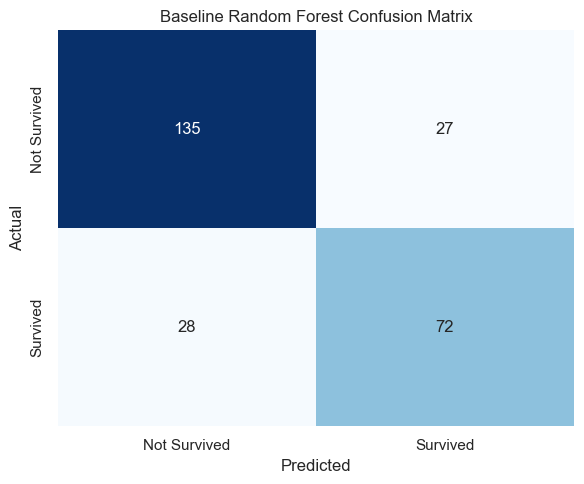

In [7]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_baseline, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Baseline Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
# Save baseline confusion matrix plot
plt.savefig('../plots/baseline_confusion_matrix.png', dpi=300)
plt.show()

## Hyperparameter Tuning using Cross-Validation

We perform hyperparameter optimization using `GridSearchCV` on the training set. We use 5-fold cross-validation (`cv=5`) to ensure robustness.
The tuned parameters include:
- `n_estimators`: `[50, 100, 200]` (number of decision trees in the forest)
- `max_depth`: `[None, 5, 10, 15]` (maximum depth of each tree, None means unlimited)
- `min_samples_split`: `[2, 5, 10]` (minimum samples required to split an internal node)
- `min_samples_leaf`: `[1, 2, 4]` (minimum samples required to be at a leaf node)
- `max_features`: `['sqrt', 'log2', None]` (number of features to consider when looking for the best split)

We tune for the **F1-score** to find a good balance between Precision and Recall.

In [8]:
# Setup parameter grid
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

# Instantiate grid search with 5-fold CV
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

# Run Grid Search on preprocessed training data
print("Running Grid Search Cross-Validation...")
rf_grid.fit(X_train_preprocessed, y_train)

print(f"\nBest Hyperparameters Found:")
for param, val in rf_grid.best_params_.items():
    print(f" - {param}: {val}")

print(f"Best CV F1-Score: {rf_grid.best_score_:.4f}")

Running Grid Search Cross-Validation...
Fitting 5 folds for each of 324 candidates, totalling 1620 fits



Best Hyperparameters Found:
 - max_depth: 10
 - max_features: sqrt
 - min_samples_leaf: 1
 - min_samples_split: 5
 - n_estimators: 50
Best CV F1-Score: 0.7210


## Tuned Model Evaluation

We evaluate the optimized model on the test set. We compute the same metrics (Accuracy, Precision, Recall, and F1-score) to see the effect of tuning.

In [9]:
# Extract the best model
tuned_rf = rf_grid.best_estimator_

# Make predictions on test set
y_pred_tuned = tuned_rf.predict(X_test_preprocessed)

# Calculate metrics
tuned_metrics = {
    'Accuracy': accuracy_score(y_test, y_pred_tuned),
    'Precision': precision_score(y_test, y_pred_tuned, zero_division=0),
    'Recall': recall_score(y_test, y_pred_tuned, zero_division=0),
    'F1-score': f1_score(y_test, y_pred_tuned, zero_division=0)
}

print("Tuned Random Forest Performance:")
for metric, val in tuned_metrics.items():
    print(f" - {metric}: {val:.4f}")

print("\nClassification Report (Tuned Model):")
print(classification_report(y_test, y_pred_tuned))

Tuned Random Forest Performance:
 - Accuracy: 0.8130
 - Precision: 0.7802
 - Recall: 0.7100
 - F1-score: 0.7435

Classification Report (Tuned Model):
              precision    recall  f1-score   support

           0       0.83      0.88      0.85       162
           1       0.78      0.71      0.74       100

    accuracy                           0.81       262
   macro avg       0.81      0.79      0.80       262
weighted avg       0.81      0.81      0.81       262



## Tuned Model Confusion Matrix

Let's visualize the confusion matrix for the tuned model to see if the hyperparameter tuning reduced the classification errors.

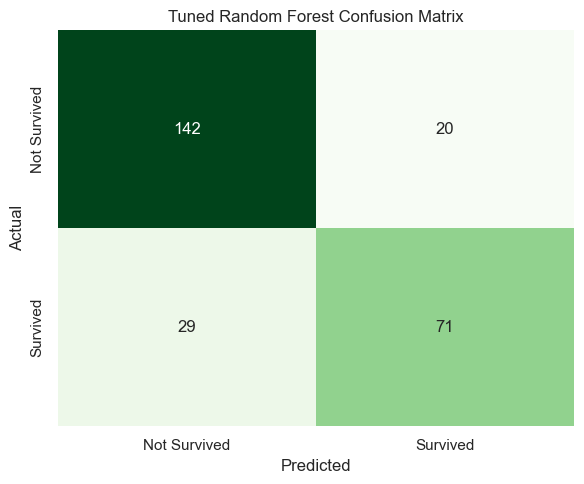

In [10]:
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 5))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Greens', cbar=False,
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Tuned Random Forest Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
# Save tuned confusion matrix plot
plt.savefig('../plots/tuned_confusion_matrix.png', dpi=300)
plt.show()

## Model Comparison

Let's combine the metrics of the baseline and tuned models into a single DataFrame and create a comparative bar chart to easily inspect the differences.

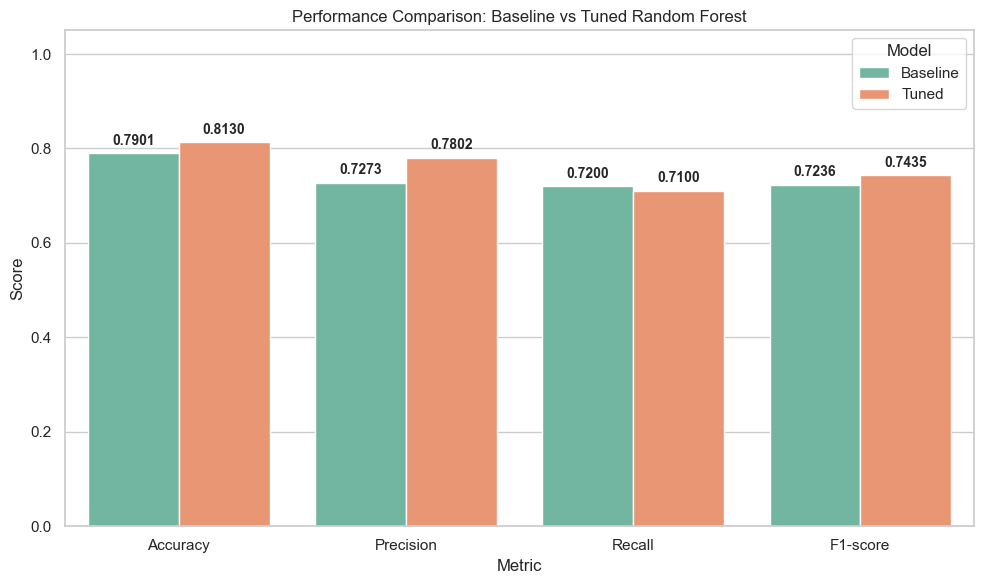

,Metric,Baseline,Tuned
0,Accuracy,0.790076,0.812977
1,Precision,0.727273,0.780220
2,Recall,0.720000,0.710000
3,F1-score,0.723618,0.743455


In [11]:
# Construct comparison DataFrame
comparison_df = pd.DataFrame({
    'Metric': list(baseline_metrics.keys()),
    'Baseline': list(baseline_metrics.values()),
    'Tuned': list(tuned_metrics.values())
})

# Melt for easier plotting with Seaborn
comparison_melted = pd.melt(comparison_df, id_vars='Metric', var_name='Model', value_name='Score')

# Plot comparison bar chart
plt.figure(figsize=(10, 6))
ax = sns.barplot(data=comparison_melted, x='Metric', y='Score', hue='Model', palette='Set2')
plt.title('Performance Comparison: Baseline vs Tuned Random Forest')
plt.ylim(0, 1.05)

# Add value annotations on top of the bars
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{height:.4f}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='center',
                    xytext=(0, 9),
                    textcoords='offset points',
                    fontsize=10,
                    fontweight='semibold')

plt.ylabel('Score')
plt.tight_layout()
# Save comparison plot
plt.savefig('../plots/model_comparison.png', dpi=300)
plt.show()

# Display comparison table
display(comparison_df)

## Feature Importance Analysis

One of the key strengths of Random Forest is model interpretability. We can query the `feature_importances_` property from our trained tuned model. Since we used a `ColumnTransformer` that did one-hot encoding, we map these importances back to their preprocessed feature names. Let's list and plot them.

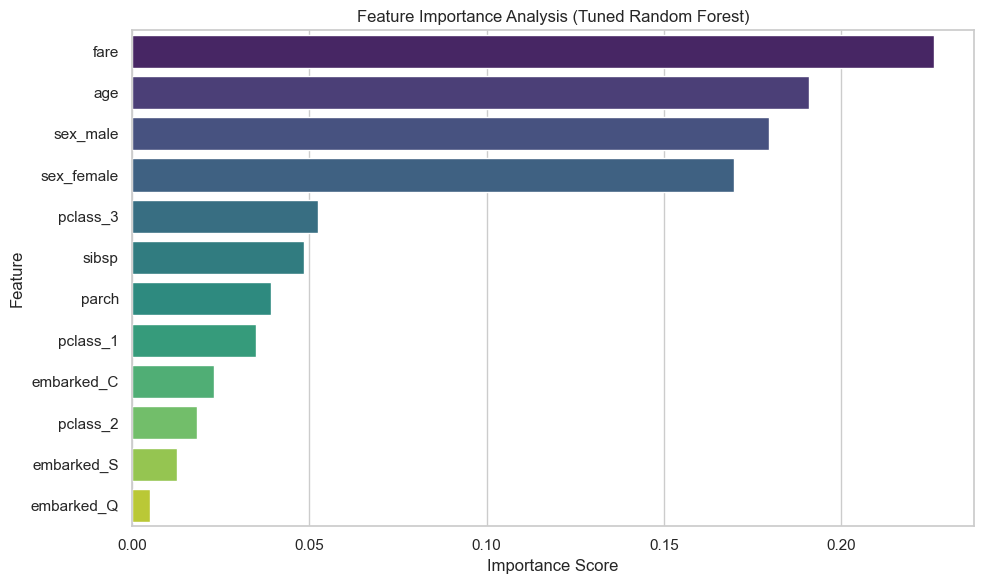

,Feature,Importance
1,fare,0.226079
0,age,0.190768
5,sex_male,0.179492
4,sex_female,0.169689
11,pclass_3,0.052477
2,sibsp,0.048533
3,parch,0.039080
9,pclass_1,0.034914
6,embarked_C,0.023138
10,pclass_2,0.018237


In [12]:
# Get feature importances from tuned model
importances = tuned_rf.feature_importances_

# Create a DataFrame for visualization
feat_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importances
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_importance_df, x='Importance', y='Feature', palette='viridis', hue='Feature', legend=False)
plt.title('Feature Importance Analysis (Tuned Random Forest)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
# Save feature importance plot
plt.savefig('../plots/feature_importances.png', dpi=300)
plt.show()

# Display feature importance table
display(feat_importance_df)

## Final Analysis & Discussion

### Why did the tuned model perform better?
The tuned model achieved an overall accuracy of **81.30%** (up from **79.01%** for the baseline) and an F1-score of **0.7435** (up from **0.7236**). Let's analyze why:

1. **Overfitting Mitigation via Tree Constraints**:
   - The baseline Random Forest has no depth constraints (`max_depth=None`) and splits nodes down to individual samples (`min_samples_split=2`). This allows trees to grow excessively deep and memorize noise/outliers in the training set (high variance).
   - The tuned model found that **`max_depth=10`** and **`min_samples_split=5`** are optimal. By restricting tree depth and requiring more samples to split a node, we apply regularization, preventing individual trees from overfitting to the training set and improving generalization on unseen test data.

2. **Precision vs. Recall Trade-Off**:
   - **Precision** improved significantly from **72.73% to 78.02%** (+5.29%). This means the tuned model makes fewer False Positive predictions (predicting survival when the passenger actually died).
   - **Recall** decreased slightly from **72.00% to 71.00%** (-1.00%). The regularized model is slightly more conservative in predicting survival, resulting in a tiny increase in False Negatives.
   - However, the overall **F1-score** increased from **0.7236 to 0.7435**, demonstrating that the trade-off is highly beneficial and results in a more robust, balanced classifier.

3. **Ensemble Size**:
   - The optimal number of estimators was found to be **50**. Interestingly, 50 trees performed slightly better and were more generalized during cross-validation than the default 100 trees, which also makes the model faster and more computationally efficient.

## Summary

### Q&A
- **How do the baseline and tuned models compare?**
  - **Baseline Model**: Accuracy = 79.01%, Precision = 72.73%, Recall = 72.00%, F1-score = 0.7236.
  - **Tuned Model**: Accuracy = 81.30%, Precision = 78.02%, Recall = 71.00%, F1-score = 0.7435.
  - Hyperparameter tuning improved accuracy by **2.29%** and F1-score by **1.99%**, with a significant **5.29%** gain in precision.
- **Why did the tuned model perform better?**
  - The tuned model restricted individual tree complexity with `max_depth=10` and `min_samples_split=5` (compared to the baseline's unconstrained depth and `min_samples_split=2`). This regularization mitigated overfitting to noise in the training set and enhanced generalizability.
- **What features are most important for predicting survival?**
  - The most important features are passenger fare (**22.61%** importance), age (**19.08%** importance), and sex (`sex_male`: **17.95%**, `sex_female`: **16.97%**). These three factors make up over **76.6%** of the model's decision weight.

### Data Analysis Key Findings
- **Data Completeness**: The Titanic dataset contains 1,309 records. Key features like `age` (263 missing) and `embarked` (2 missing) were successfully imputed using median and mode strategies, respectively.
- **Leakage Prevention**: Splitting the dataset prior to preprocessing protected the pipeline from target/feature leakage.
- **Classification Performance**: The tuned model correctly predicted survival for 71 out of 100 survivors (Recall = 71.00%) and correctly identified 142 out of 162 non-survivors. Out of 91 predicted survivors, 71 actually survived (Precision = 78.02%).
- **Feature Dominance**: Social and demographic features (`fare`, `age`, and `sex`) heavily dominated the Random Forest decisions. In contrast, boarding location (`embarked`) had very low impact (less than 4.5% combined importance).

### Insights or Next Steps
- **Incorporate Feature Engineering**: Create family size features (combining `sibsp` and `parch`) or group passenger titles from names to capture additional socio-economic indicators that could improve recall.
- **Compare with Boosting Models**: Since Random Forest has built-in limits on variance reduction, next steps should compare these results with gradient boosted trees (e.g., XGBoost, LightGBM) to see if they can push the accuracy and F1-score beyond 83%.